<a href="https://colab.research.google.com/github/optofficial2026/2026-OPT-1st-Homework/blob/jeongbyeol/Week3/3%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C_%EC%A0%95%EB%B3%84_CIFAR10_CNN_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Neural Network on CIFAR-10 with Regularization

In this assignment, you will:
1. Build a baseline CNN for CIFAR-10 classification
2. Implement and compare regularization techniques (Dropout, BatchNorm)
3. Combine all techniques to build your best model
4. Visualize how CNNs learn (filters, feature maps, Grad-CAM)
5. Analyze and compare results

**Rules:**
- You may use PyTorch (or TensorFlow if you prefer)
- Do NOT use pretrained models
- Fill in all `# TODO` sections
- Report final test accuracy for each experiment

---

## Grading Rubric

Your grade is determined by your **Best Model** (Task 4) **final test accuracy**, evaluated in Task 6:

| Grade | Test Accuracy | Description |
|-------|--------------|-------------|
| **A+** | >= 85% | Excellent — strong architecture with well-tuned regularization |
| **A** | >= 82% | Great — good combination of techniques |
| **B+** | >= 79% | Good effort — room for optimization |
| **B** | >= 76% | Decent — used some techniques effectively |
| **C** | >= 70% | Minimal effort — near baseline performance |
| **F** | < 70% | Needs more work |

**Per-task minimum thresholds** (must pass all to receive full credit):
- Task 1 (Baseline): >= 65% — confirms a working CNN
- Task 2 (Dropout): >= 65%
- Task 3 (BatchNorm): >= 70%
- Task 4 (Best Model): >= 70%
- Task 5 (Visualization): Complete all visualizations and answer questions
- Task 6 (Analysis): Answer all questions thoughtfully

## 0. Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

# CUDA — NVIDIA GPU (가장 빠름)
# MPS — Apple Silicon Mac (M1/M2/M3)
# CPU — fallback
# -> NVIDIA gpu사용으로 결과나옴

Using device: cuda


## 1. Data Loading

CIFAR-10: 60,000 32x32 color images in 10 classes (50k train, 10k test).

We split the training set into **train (45k)** and **validation (5k)** so that we tune hyperparameters on the validation set and only evaluate on the test set at the very end.



*   Train: 모델학습
*   Validation: 하이퍼파라미터튜닝
* Test: 최종 성능평가


* **하이퍼파라미터(Hyperparameter)**:
모델이 학습하면서 스스로 찾는 값이 아니라, 사람이 직접 설정해줘야 하는 값들
+ But 모델이 스스로 학습하는 값은 가중치(weight), 편향(bias) 같은 파라미터

* **튜닝(Tuning)**
하이퍼파라미터를 이것저것 바꿔보면서 가장 성능이 좋은 조합을 찾는 과정입니다.

예를 들어: lr = 0.01로 해봤더니 학습이 불안정 → 0.001로 줄여봄
batch_size = 128이 64보다 빠르지만 성능이 낮음 → 64 선택

**+CIFAR-10 이미지가 컴퓨터에 저장되는 방식**

In [2]:
# 32 × 32 × 3
#  ↑    ↑   ↑
# 가로  세로  채널(R, G, B)

# 32×32 픽셀짜리 이미지인데, R(빨강)/G(초록)/B(파랑) 3장의 격자로 이루어져 있어요

In [3]:
# Basic transform (no augmentation yet)
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Full training set (we will split into train + val)
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_basic)

# Split: 45k train, 5k validation
trainset, valset = torch.utils.data.random_split(full_trainset, [45000, 5000],
                                                  generator=torch.Generator().manual_seed(42))

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=128, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


**valset(trainset) vs valloader(trainloader)**

비유하자면:

valset = 책장에 꽂힌 책들/
valloader = 책을 한 번에 128권씩 꺼내주는 사서

**모델은 이미지 1장씩이 아니라 128장(batch) 묶음으로 학습하기 때문에, DataLoader가 반드시 필요합니다.** valset만으로는 학습 루프에 바로 쓸 수 없어요.



## 2. Training & Evaluation Helpers

> **Note:** Dropout and BatchNorm behave differently during training vs. evaluation. The `train()` function calls `model.train()` and `evaluate()` calls `model.eval()` — this is critical for correct results.

**에폭(Epoch)이란?**

* 훈련 데이터 전체를 한 번 다 봤다 = 1 에폭
* CIFAR-10 훈련 데이터가 45,000장인데, 배치가 128장이니까:

  45,000 ÷ 128 = 약 352번 반복 = 1 에폭
  20 에폭 = 전체 데이터를 20번 반복해서 봄

In [4]:
def train(model, loader, criterion, optimizer, epochs=20, scheduler=None):
    """Train the model. Returns lists of (train_loss, train_acc) per epoch."""
    model.train()
    history = {'loss': [], 'acc': []}
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        if scheduler is not None: #Task4에서 사용 예정
            scheduler.step()

        print(f'Epoch {epoch+1:2d}/{epochs} \u2014 Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')
    return history


def evaluate(model, loader):
    """Evaluate the model on a dataset. Returns (loss, accuracy)."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

**CNN이 하는일(강독자료 기준)**

Input → [Conv+ReLU → Pooling] 반복 → Flatten → FC Layer → Output(확률)


---
## Task 1: Baseline CNN (No Regularization)

Build a simple CNN. Suggested architecture:
- 2~3 Conv blocks (Conv2d -> ReLU -> MaxPool2d)
- 1~2 Fully connected layers
- No dropout, no batch norm, no weight decay

In [5]:
class BaselineCNN(nn.Module):
    def __init__(self):              # drop_rate 파라미터 제거
        super().__init__()
        # TODO: Define your layers

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

# 128 * 4 * 4 = 2048 이 숫자가 어디서 왔냐면:
# Conv3 통과 후 크기: 128채널 ×     4×4
#                     ↑         ↑
#                 필터 128개   Pool 3번으로 줄어든 크기
#                              (32→16→8→4)
# 이걸 일렬로 쭉 펼치면 = 128 × 4 × 4 = 2048개 숫자

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
          #                   ↑    ↑
          #                 입력  출력(클래스 수)

          # 최종적으로 **10개 클래스** 확률로 변환

          # 256개 숫자 → 10개 숫자
          #              [비행기:0.1, 자동차:0.7, 새:0.05, ...]
          #                               ↑
          #                          가장 높은게 예측 결과

    def forward(self, x):
        # TODO: Implement forward pass
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

baseline = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

hist_baseline = train(baseline, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(baseline, valloader)
print(f'\n[Baseline] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.4241, Acc: 0.4840
Epoch  2/20 — Loss: 1.0178, Acc: 0.6390
Epoch  3/20 — Loss: 0.8182, Acc: 0.7136
Epoch  4/20 — Loss: 0.6957, Acc: 0.7548
Epoch  5/20 — Loss: 0.5873, Acc: 0.7956
Epoch  6/20 — Loss: 0.4939, Acc: 0.8284
Epoch  7/20 — Loss: 0.4050, Acc: 0.8574
Epoch  8/20 — Loss: 0.3288, Acc: 0.8844
Epoch  9/20 — Loss: 0.2596, Acc: 0.9088
Epoch 10/20 — Loss: 0.1988, Acc: 0.9304
Epoch 11/20 — Loss: 0.1522, Acc: 0.9470
Epoch 12/20 — Loss: 0.1218, Acc: 0.9568
Epoch 13/20 — Loss: 0.0975, Acc: 0.9662
Epoch 14/20 — Loss: 0.0833, Acc: 0.9713
Epoch 15/20 — Loss: 0.0823, Acc: 0.9720
Epoch 16/20 — Loss: 0.0703, Acc: 0.9764
Epoch 17/20 — Loss: 0.0755, Acc: 0.9740
Epoch 18/20 — Loss: 0.0642, Acc: 0.9780
Epoch 19/20 — Loss: 0.0554, Acc: 0.9812
Epoch 20/20 — Loss: 0.0583, Acc: 0.9794

[Baseline] Val Accuracy: 0.7432


In [6]:
# 출력된 결과값
# Epoch  1/20 — Loss: 1.4176, Acc: 0.4897
# Epoch  2/20 — Loss: 0.9924, Acc: 0.6501
# Epoch  3/20 — Loss: 0.8109, Acc: 0.7146
# Epoch  4/20 — Loss: 0.6828, Acc: 0.7617
# Epoch  5/20 — Loss: 0.5849, Acc: 0.7965
# Epoch  6/20 — Loss: 0.4935, Acc: 0.8286
# Epoch  7/20 — Loss: 0.4061, Acc: 0.8586
# Epoch  8/20 — Loss: 0.3255, Acc: 0.8858
# Epoch  9/20 — Loss: 0.2576, Acc: 0.9087
# Epoch 10/20 — Loss: 0.1945, Acc: 0.9324
# Epoch 11/20 — Loss: 0.1468, Acc: 0.9481
# Epoch 12/20 — Loss: 0.1160, Acc: 0.9595
# Epoch 13/20 — Loss: 0.1034, Acc: 0.9638
# Epoch 14/20 — Loss: 0.0796, Acc: 0.9723
# Epoch 15/20 — Loss: 0.0727, Acc: 0.9746
# Epoch 16/20 — Loss: 0.0769, Acc: 0.9734
# Epoch 17/20 — Loss: 0.0661, Acc: 0.9765
# Epoch 18/20 — Loss: 0.0671, Acc: 0.9766
# Epoch 19/20 — Loss: 0.0559, Acc: 0.9816
# Epoch 20/20 — Loss: 0.0597, Acc: 0.9788

# [Baseline] Val Accuracy: 0.7506


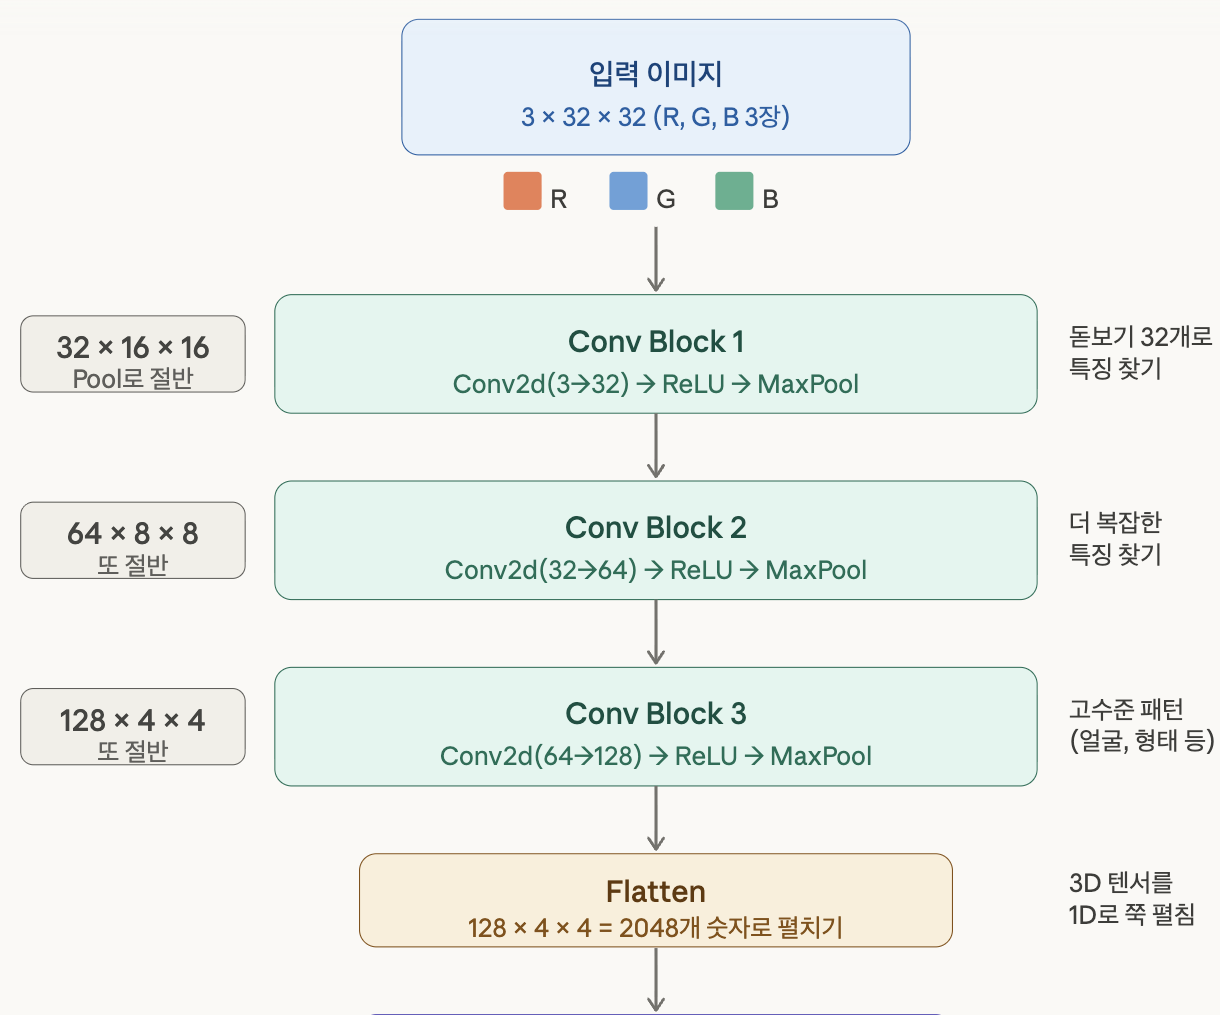

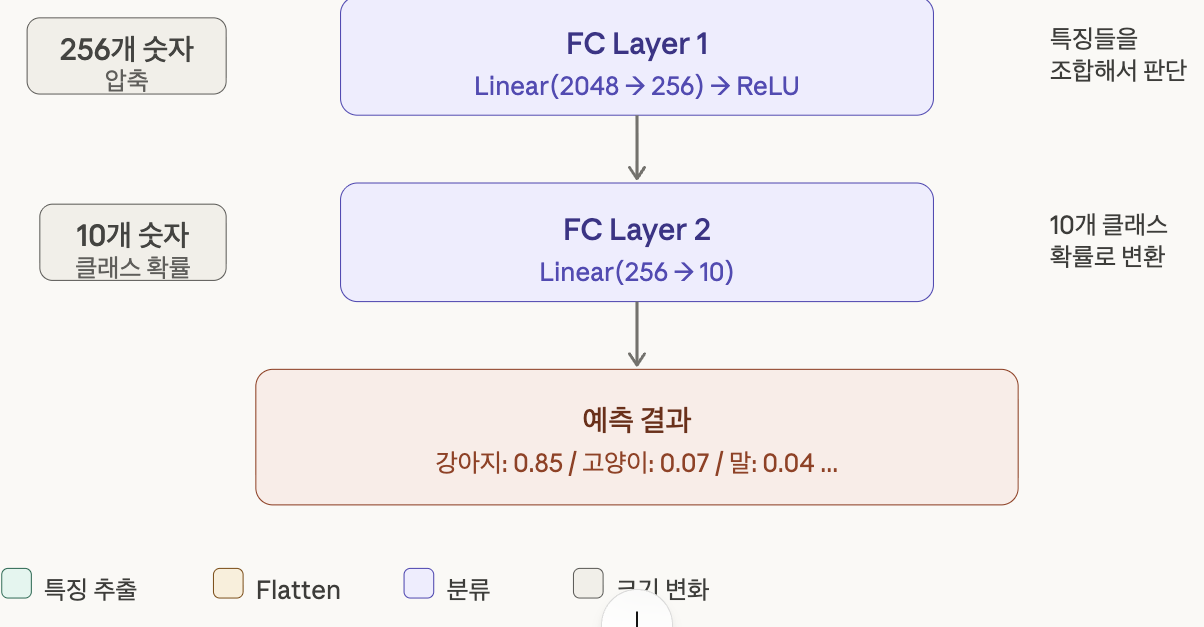

---
## Task 2: Dropout Regularization

Copy your baseline and add **Dropout** layers. Experiment with dropout rates (e.g., 0.25, 0.5).

> **Tip:** Start with a lower rate like 0.25. High dropout (0.5) on small networks with few epochs can hurt training convergence — this is itself a useful observation.

In [7]:
class DropoutCNN(nn.Module):
    def __init__(self, drop_rate=0.25):
        super().__init__()
        # TODO: Same architecture as baseline + Dropout layers

        # Baseline과 동일한 Conv 구조(Task1)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        # Dropout 추가(이 지점이 추가된 것임)
          #50%의 뉴런을 랜덤으로 0으로 바꿔즈는 것
            #FC에 0.5 쓰는 이유: FC Layer는 파라미터 수가 Conv보다 훨씬 많아서 과적합이 더 잘 생김.
            #그래서 더 강하게 Dropout을 주는 것
        self.drop  = nn.Dropout(p=drop_rate)    # Conv 이후
        self.drop_fc = nn.Dropout(p=0.5)        # FC 이후 (더 강하게)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        pass

    def forward(self, x):
        # TODO
        x = self.drop(self.pool(torch.relu(self.conv1(x))))
        x = self.drop(self.pool(torch.relu(self.conv2(x))))
        x = self.drop(self.pool(torch.relu(self.conv3(x))))
        x = x.view(x.size(0), -1)

        x = self.drop_fc(torch.relu(self.fc1(x))) #Baseline에서 이 부분만 추가됨.Conv/FC 이후에 Dropout 적용
        x = self.fc2(x)
        return x


dropout_model = DropoutCNN(drop_rate=0.25).to(device)
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

hist_dropout = train(dropout_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(dropout_model, valloader)
print(f'\n[Dropout] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.6351, Acc: 0.3998
Epoch  2/20 — Loss: 1.2612, Acc: 0.5464
Epoch  3/20 — Loss: 1.1204, Acc: 0.6045
Epoch  4/20 — Loss: 1.0241, Acc: 0.6371
Epoch  5/20 — Loss: 0.9535, Acc: 0.6654
Epoch  6/20 — Loss: 0.9055, Acc: 0.6836
Epoch  7/20 — Loss: 0.8551, Acc: 0.7012
Epoch  8/20 — Loss: 0.8251, Acc: 0.7110
Epoch  9/20 — Loss: 0.7947, Acc: 0.7209
Epoch 10/20 — Loss: 0.7783, Acc: 0.7262
Epoch 11/20 — Loss: 0.7515, Acc: 0.7378
Epoch 12/20 — Loss: 0.7353, Acc: 0.7429
Epoch 13/20 — Loss: 0.7165, Acc: 0.7486
Epoch 14/20 — Loss: 0.7058, Acc: 0.7537
Epoch 15/20 — Loss: 0.6897, Acc: 0.7583
Epoch 16/20 — Loss: 0.6732, Acc: 0.7643
Epoch 17/20 — Loss: 0.6582, Acc: 0.7698
Epoch 18/20 — Loss: 0.6562, Acc: 0.7679
Epoch 19/20 — Loss: 0.6386, Acc: 0.7752
Epoch 20/20 — Loss: 0.6233, Acc: 0.7792

[Dropout] Val Accuracy: 0.7840


In [8]:
# 출력된 결과값
# Epoch  1/20 — Loss: 1.6477, Acc: 0.3952
# Epoch  2/20 — Loss: 1.2975, Acc: 0.5340
# Epoch  3/20 — Loss: 1.1505, Acc: 0.5928
# Epoch  4/20 — Loss: 1.0590, Acc: 0.6260
# Epoch  5/20 — Loss: 0.9845, Acc: 0.6533
# Epoch  6/20 — Loss: 0.9281, Acc: 0.6742
# Epoch  7/20 — Loss: 0.8887, Acc: 0.6887
# Epoch  8/20 — Loss: 0.8532, Acc: 0.7001
# Epoch  9/20 — Loss: 0.8188, Acc: 0.7143
# Epoch 10/20 — Loss: 0.7977, Acc: 0.7190
# Epoch 11/20 — Loss: 0.7744, Acc: 0.7310
# Epoch 12/20 — Loss: 0.7519, Acc: 0.7375
# Epoch 13/20 — Loss: 0.7353, Acc: 0.7416
# Epoch 14/20 — Loss: 0.7185, Acc: 0.7469
# Epoch 15/20 — Loss: 0.7033, Acc: 0.7534
# Epoch 16/20 — Loss: 0.6913, Acc: 0.7577
# Epoch 17/20 — Loss: 0.6835, Acc: 0.7592
# Epoch 18/20 — Loss: 0.6675, Acc: 0.7674
# Epoch 19/20 — Loss: 0.6664, Acc: 0.7666
# Epoch 20/20 — Loss: 0.6423, Acc: 0.7752

# [Dropout] Val Accuracy: 0.7774

**왜 Train(77.52%) 보다 Val(77.74%)이 더 높은가?**

바로 `model.eval()` 때문입니다!
```
학습 중 (train):
→ Dropout이 켜져 있음
→ 뉴런 25%~50%가 랜덤으로 꺼진 상태로 예측
→ 일부러 어렵게 학습 = Acc가 낮게 측정됨

평가 중 (eval):
→ Dropout이 꺼짐
→ 모든 뉴런 다 켜진 상태로 예측
→ 풀 파워로 예측 = Acc가 더 높게 측정됨

---
## Task 3: Batch Normalization

Copy your baseline and add **BatchNorm2d** (after conv layers) and/or **BatchNorm1d** (after FC layers).

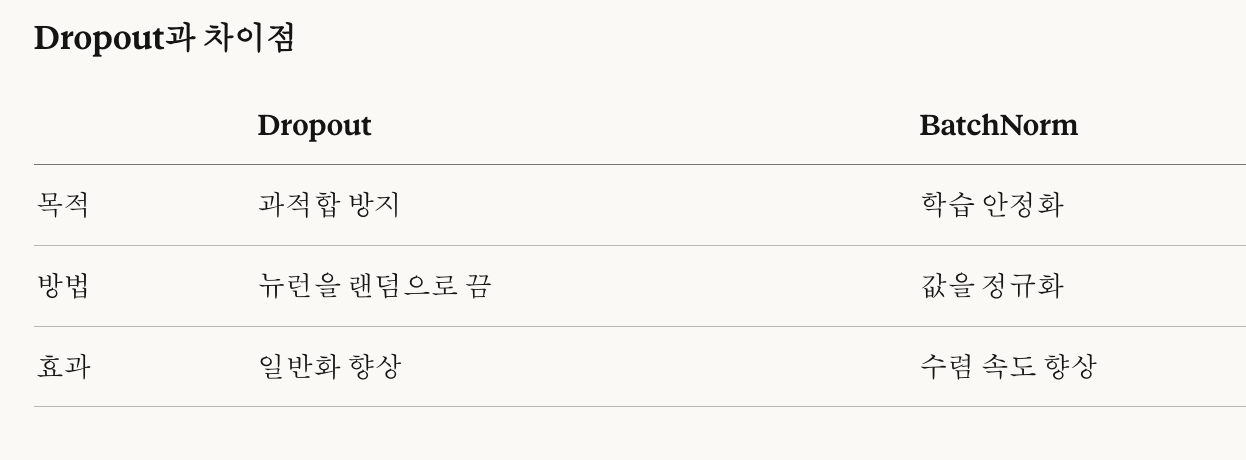

In [9]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Same architecture as baseline + BatchNorm layers

        # Conv 레이어
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)   # conv1 출력 채널 수와 동일하게 맞춰야함
                                          # BatchNorm은 채널별로 정규화하기 때문

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)   # conv2 출력 채널 수와 동일

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)  # conv3 출력 채널 수와 동일

        self.pool  = nn.MaxPool2d(2, 2)

        # FC 레이어
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.bn4 = nn.BatchNorm1d(256)    # fc1 출력 크기와 동일하게 맞춰야함ㅇㅇ
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # forward에서 순서: Conv → BN → ReLU → Pool
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        #                         ↑ Conv 직후, ReLU 직전에 적용

        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.bn4(self.fc1(x)))
        x = self.fc2(x)
        return x


bn_model = BatchNormCNN().to(device)
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

hist_bn = train(bn_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(bn_model, valloader)
print(f'\n[BatchNorm] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.0826, Acc: 0.6160
Epoch  2/20 — Loss: 0.7302, Acc: 0.7464
Epoch  3/20 — Loss: 0.5663, Acc: 0.8021
Epoch  4/20 — Loss: 0.4406, Acc: 0.8481
Epoch  5/20 — Loss: 0.3314, Acc: 0.8864
Epoch  6/20 — Loss: 0.2451, Acc: 0.9199
Epoch  7/20 — Loss: 0.1719, Acc: 0.9450
Epoch  8/20 — Loss: 0.1229, Acc: 0.9619
Epoch  9/20 — Loss: 0.0891, Acc: 0.9736
Epoch 10/20 — Loss: 0.0788, Acc: 0.9748
Epoch 11/20 — Loss: 0.0663, Acc: 0.9804
Epoch 12/20 — Loss: 0.0559, Acc: 0.9834
Epoch 13/20 — Loss: 0.0516, Acc: 0.9842
Epoch 14/20 — Loss: 0.0523, Acc: 0.9833
Epoch 15/20 — Loss: 0.0433, Acc: 0.9867
Epoch 16/20 — Loss: 0.0359, Acc: 0.9894
Epoch 17/20 — Loss: 0.0590, Acc: 0.9792
Epoch 18/20 — Loss: 0.0485, Acc: 0.9842
Epoch 19/20 — Loss: 0.0302, Acc: 0.9910
Epoch 20/20 — Loss: 0.0223, Acc: 0.9936

[BatchNorm] Val Accuracy: 0.7686


In [10]:
# 실제 출력값
# Epoch  1/20 — Loss: 1.0900, Acc: 0.6134
# Epoch  2/20 — Loss: 0.7201, Acc: 0.7489
# Epoch  3/20 — Loss: 0.5679, Acc: 0.8021
# Epoch  4/20 — Loss: 0.4427, Acc: 0.8480
# Epoch  5/20 — Loss: 0.3333, Acc: 0.8873
# Epoch  6/20 — Loss: 0.2390, Acc: 0.9211
# Epoch  7/20 — Loss: 0.1753, Acc: 0.9440
# Epoch  8/20 — Loss: 0.1242, Acc: 0.9608
# Epoch  9/20 — Loss: 0.0887, Acc: 0.9742
# Epoch 10/20 — Loss: 0.0752, Acc: 0.9777
# Epoch 11/20 — Loss: 0.0728, Acc: 0.9775
# Epoch 12/20 — Loss: 0.0601, Acc: 0.9819
# Epoch 13/20 — Loss: 0.0477, Acc: 0.9857
# Epoch 14/20 — Loss: 0.0553, Acc: 0.9821
# Epoch 15/20 — Loss: 0.0527, Acc: 0.9830
# Epoch 16/20 — Loss: 0.0433, Acc: 0.9865
# Epoch 17/20 — Loss: 0.0351, Acc: 0.9895
# Epoch 18/20 — Loss: 0.0381, Acc: 0.9876
# Epoch 19/20 — Loss: 0.0439, Acc: 0.9857
# Epoch 20/20 — Loss: 0.0418, Acc: 0.9856

# [BatchNorm] Val Accuracy: 0.7512

---
## Task 4: Best Model — Combine Everything

Now combine the techniques that worked best. Try to **maximize validation accuracy**. (Final test accuracy is evaluated once in Task 6.)

You may use any combination of:
- 01 BatchNorm, Dropout
- 02 Weight decay (`weight_decay` parameter in optimizer)
- 03 Data augmentation (e.g., `RandomHorizontalFlip`, `RandomCrop`, `ColorJitter`)
  - transforms.RandomHorizontalFlip()  # 이미지를 랜덤으로 좌우 반전
  - transforms.RandomCrop(32, padding=4)  # 랜덤으로 잘라내기
  - transforms.ColorJitter(...)  # 밝기/색상 랜덤 변환
  - -> 훈련 데이터를 인위적으로 늘리는 방법입니다. 같은 고양이 사진을 뒤집거나 잘라서 "새로운 데이터"처럼 사용합니다.

- 04 Deeper/wider architectures # 10 에폭마다 lr을 0.1배로 줄임
- 05 Learning rate scheduling (`optim.lr_scheduler`)
- 06 More epochs #더 오래 학습할 수록 성능 향상
- 07 Different optimizers (SGD + momentum) #Adam 대신 SGD를 쓰는 방법입니다. 잘 튜닝하면 Adam보다 성능이 높게 나오는 경우가 많습니다.


In [11]:
# # 훈련 데이터를 '인위적으로 변형'해서 데이터가 더 많은 것처럼 학습시키는 기법입니다.
# RandomHorizontalFlip:
# 고양이 사진 → 50% 확률로 → 좌우 반전된 고양이 사진
# (고양이는 뒤집어도 고양이니까 정답 레이블은 그대로)

# RandomCrop(32, padding=4):
# 테두리에 빈칸 4픽셀 추가 후 → 랜덤 위치에서 32×32 잘라냄
# → 이미지 위치가 조금씩 달라짐

# ColorJitter:
# 밝기/대비/채도를 ±20% 범위에서 랜덤 변환
# → 어두운 사진, 밝은 사진 등 다양한 환경 학습

# 왜 하냐? → 모델이 "고양이는 항상 이 위치, 이 밝기" 라고 외우지 못하게 하기 위해서입니다.


# (Optional) Define an augmented transform for better training
transform_aug = transforms.Compose([
    # TODO: Add augmentation transforms here (e.g., RandomHorizontalFlip, RandomCrop)

    transforms.RandomHorizontalFlip(),          # 50% 확률로 좌우 반전
    transforms.RandomCrop(32, padding=4),       # 랜덤 크롭
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 색상 변환

    transforms.ToTensor(), #기존코드
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)) #기존코드
])

full_trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)
trainset_aug, _ = torch.utils.data.random_split(full_trainset_aug, [45000, 5000],
                                                 generator=torch.Generator().manual_seed(42))
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=128, shuffle=True, num_workers=2)


class BestCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Your best architecture with all regularization techniques combined
        # Conv Block 1 (채널 넓힘: 64)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)

        # Conv Block 2 (128)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(128)

        # Conv Block 3 (256)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(256)

        # Conv Block 4 추가 (256 유지, Pool 없음)
        self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)

        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=0.3)

        # FC Layers
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.bn5 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # TODO
        # Block 1
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))   # 64 × 16 × 16
        x = self.dropout(x)

        # Block 2
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))   # 128 × 8 × 8
        x = self.dropout(x)

        # Block 3
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))   # 256 × 4 × 4
        x = self.dropout(x)

        # Block 4 (Pool 없음 → 크기 유지)
        x = torch.relu(self.bn4(self.conv4(x)))              # 256 × 4 × 4
        x = self.dropout(x)

        x = x.view(x.size(0), -1)                            # 256*4*4 = 4096
        x = self.dropout(torch.relu(self.bn5(self.fc1(x))))  # 512
        x = self.fc2(x)                                       # 10
        return x



best_model = BestCNN().to(device)
# TODO: Choose optimizer, weight decay, scheduler
# SGD + Momentum + Weight Decay
optimizer = optim.SGD(best_model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

# 스케줄러: 10 에폭마다 lr을 0.1배로 줄임
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


# You may use trainloader (no augmentation) or trainloader_aug (with augmentation)
hist_best = train(best_model, trainloader_aug, criterion, optimizer, epochs=30, scheduler=scheduler) #scheduler만 추가
val_loss, val_acc = evaluate(best_model, valloader)
print(f'\n[Best Model] Val Accuracy: {val_acc:.4f}')

SyntaxError: invalid character '→' (U+2192) (340863126.py, line 3)

In [ ]:
# Epoch  1/30 — Loss: 1.8618, Acc: 0.3696
# Epoch  2/30 — Loss: 1.3508, Acc: 0.5081
# Epoch  3/30 — Loss: 1.1553, Acc: 0.5842
# Epoch  4/30 — Loss: 1.0465, Acc: 0.6277
# Epoch  5/30 — Loss: 0.9702, Acc: 0.6541
# Epoch  6/30 — Loss: 0.9159, Acc: 0.6763
# Epoch  7/30 — Loss: 0.8638, Acc: 0.6958
# Epoch  8/30 — Loss: 0.8321, Acc: 0.7068
# Epoch  9/30 — Loss: 0.8024, Acc: 0.7195
# Epoch 10/30 — Loss: 0.7773, Acc: 0.7271
# Epoch 11/30 — Loss: 0.6857, Acc: 0.7602
# Epoch 12/30 — Loss: 0.6563, Acc: 0.7703
# Epoch 13/30 — Loss: 0.6440, Acc: 0.7739
# Epoch 14/30 — Loss: 0.6302, Acc: 0.7781
# Epoch 15/30 — Loss: 0.6234, Acc: 0.7812
# Epoch 16/30 — Loss: 0.6082, Acc: 0.7844
# Epoch 17/30 — Loss: 0.6134, Acc: 0.7855
# Epoch 18/30 — Loss: 0.5934, Acc: 0.7920
# Epoch 19/30 — Loss: 0.5984, Acc: 0.7912
# Epoch 20/30 — Loss: 0.5944, Acc: 0.7909
# Epoch 21/30 — Loss: 0.5784, Acc: 0.7970
# Epoch 22/30 — Loss: 0.5797, Acc: 0.7961
# Epoch 23/30 — Loss: 0.5724, Acc: 0.7998
# Epoch 24/30 — Loss: 0.5717, Acc: 0.7995
# Epoch 25/30 — Loss: 0.5678, Acc: 0.8006
# Epoch 26/30 — Loss: 0.5701, Acc: 0.8009
# Epoch 27/30 — Loss: 0.5682, Acc: 0.8020
# Epoch 28/30 — Loss: 0.5686, Acc: 0.8017
# Epoch 29/30 — Loss: 0.5715, Acc: 0.8007
# Epoch 30/30 — Loss: 0.5679, Acc: 0.8019

# [Best Model] Val Accuracy: 0.8388


---
## Task 5: Visualizing How CNNs Work

Understanding what happens inside a CNN is crucial for building intuition. In this section you will:

1. **Visualize first-layer convolutional filters** — what low-level patterns does the network learn?
2. **Visualize feature maps (activations)** — how does each layer transform the input image?
3. **Grad-CAM heatmaps** — where does the model "look" when making a prediction?
4. **Compare Baseline vs BatchNorm** — how does BatchNorm affect what the CNN learns?

The helper functions are provided below. Your job is to **call them on your trained models**, observe the outputs, and **answer the questions**.

In [12]:
# ===== Visualization Helpers (provided — do not modify) =====

def show_original_image(image, label=None):
    """Display a single CIFAR-10 image (un-normalized)."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = image.cpu() * std + mean
    img = img.clamp(0, 1)
    plt.figure(figsize=(2, 2))
    plt.imshow(img.permute(1, 2, 0).numpy())
    if label is not None:
        plt.title(f"Label: {classes[label]}")
    plt.axis('off')
    plt.show()


def _get_conv_layers(model):
    """Return an ordered list of (name, Conv2d module) from the model."""
    convs = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            convs.append((name, module))
    return convs


def visualize_filters(model, title="First Conv Layer Filters"):
    """Visualize the filters of the first Conv2d layer."""
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return
    first_conv = conv_layers[0][1]
    filters = first_conv.weight.data.cpu().clone()
    n = min(filters.shape[0], 16)
    fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
    for i, ax in enumerate(axes.flat):
        if i < n:
            f = filters[i]
            f = (f - f.min()) / (f.max() - f.min())
            ax.imshow(f.permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def visualize_feature_maps(model, image, title="Feature Maps"):
    """Visualize feature maps at each Conv2d layer for a single image."""
    model.eval()
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return

    # Register forward hooks on all conv layers
    activations = {}
    hooks = []
    for name, layer in conv_layers:
        def hook_fn(module, input, output, name=name):
            activations[name] = output.detach().cpu().squeeze(0)
        hooks.append(layer.register_forward_hook(hook_fn))

    # Forward pass
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        model(x)

    # Remove hooks
    for h in hooks:
        h.remove()

    # Plot
    for i, (name, _) in enumerate(conv_layers):
        act = activations[name]
        n_ch = min(act.shape[0], 8)
        fig, axes = plt.subplots(1, n_ch, figsize=(n_ch * 2, 2))
        if n_ch == 1:
            axes = [axes]
        for j in range(n_ch):
            axes[j].imshow(act[j], cmap='viridis')
            axes[j].axis('off')
        label = f"Conv {i+1} (ch={act.shape[0]}, {act.shape[1]}x{act.shape[2]})"
        plt.suptitle(f"{title} \u2014 {label}", fontsize=12)
        plt.tight_layout()
        plt.show()


def grad_cam(model, image, target_class=None):
    """Compute Grad-CAM heatmap for the last Conv2d layer."""
    import torch.nn.functional as F
    model.eval()

    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        raise ValueError("No Conv2d layers found in model.")
    last_conv = conv_layers[-1][1]

    gradients, activations_list = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations_list.append(output)

    handle_f = last_conv.register_forward_hook(forward_hook)
    handle_b = last_conv.register_full_backward_hook(backward_hook)

    input_tensor = image.unsqueeze(0).to(device).requires_grad_(True)
    output = model(input_tensor)
    if target_class is None:
        target_class = output.argmax(1).item()
    model.zero_grad()
    output[0, target_class].backward()

    grads = gradients[0].cpu().data.numpy()[0]
    acts = activations_list[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1, 2))
    cam = np.sum(weights[:, None, None] * acts, axis=0)
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()
    cam_resized = F.interpolate(cam_tensor, size=(32, 32), mode='bilinear', align_corners=False)
    cam_resized = cam_resized.squeeze().numpy()

    handle_f.remove()
    handle_b.remove()
    return cam_resized, target_class


def show_grad_cam(model, image, label=None, title="Grad-CAM"):
    """Display Grad-CAM heatmap overlaid on the original image."""
    cam, pred_class = grad_cam(model, image)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title("Grad-CAM")
    axes[1].axis('off')
    axes[2].imshow(img)
    axes[2].imshow(cam, cmap='jet', alpha=0.5)
    axes[2].set_title(f"Overlay (pred: {classes[pred_class]})")
    axes[2].axis('off')
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

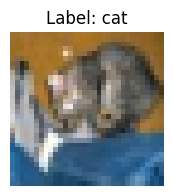

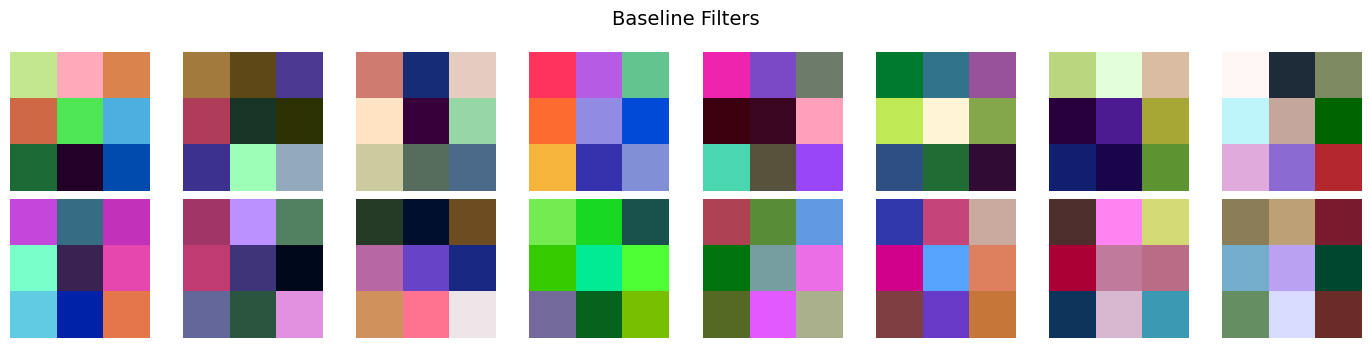

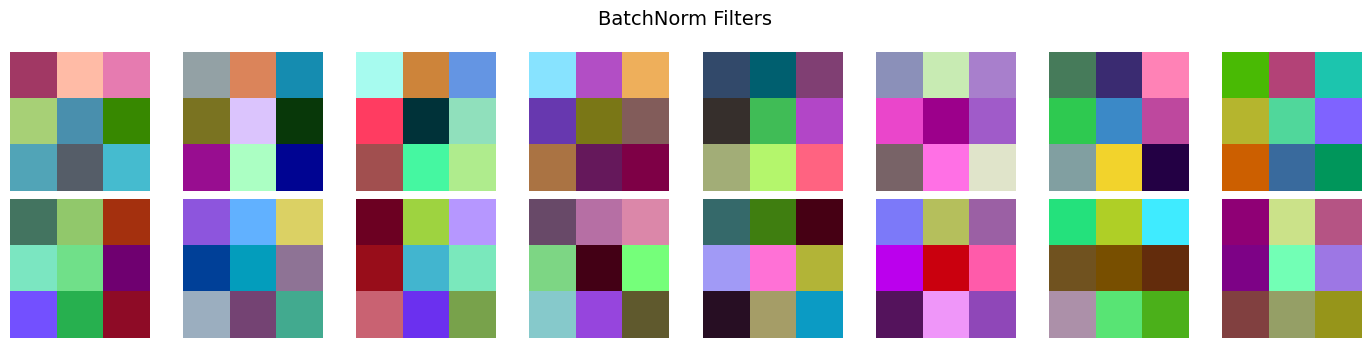

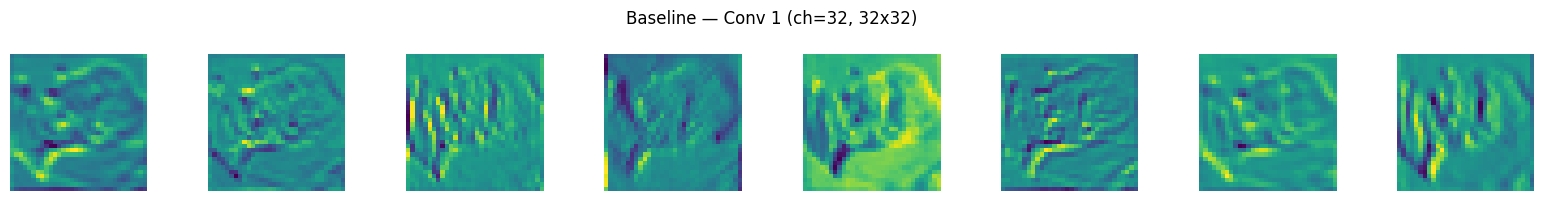

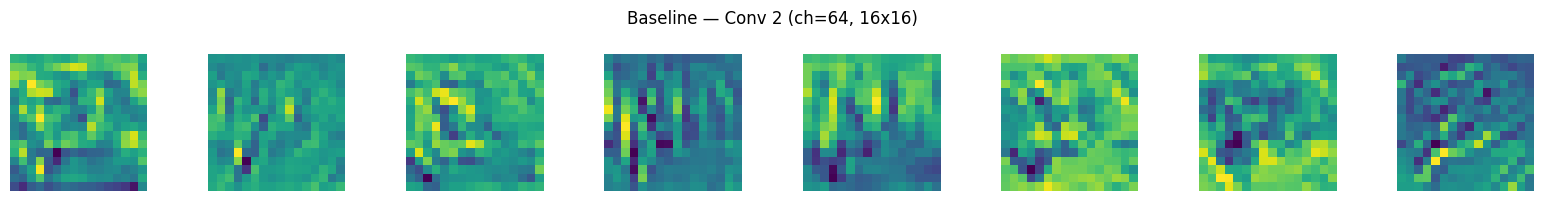

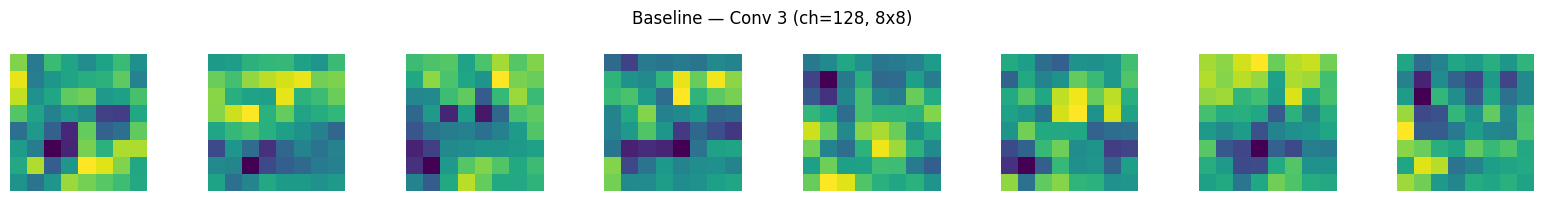

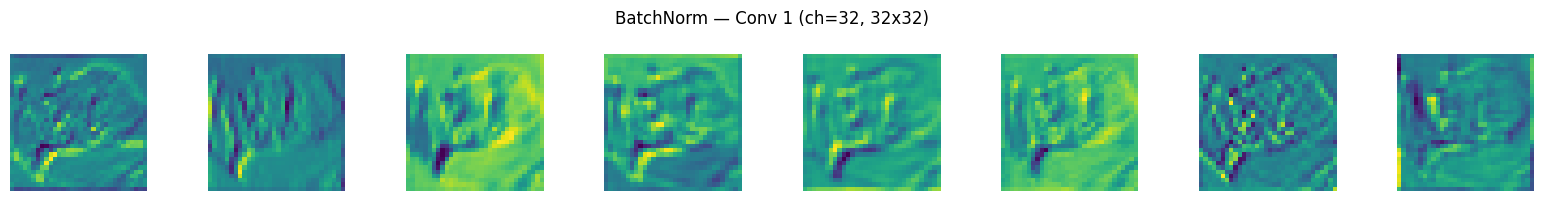

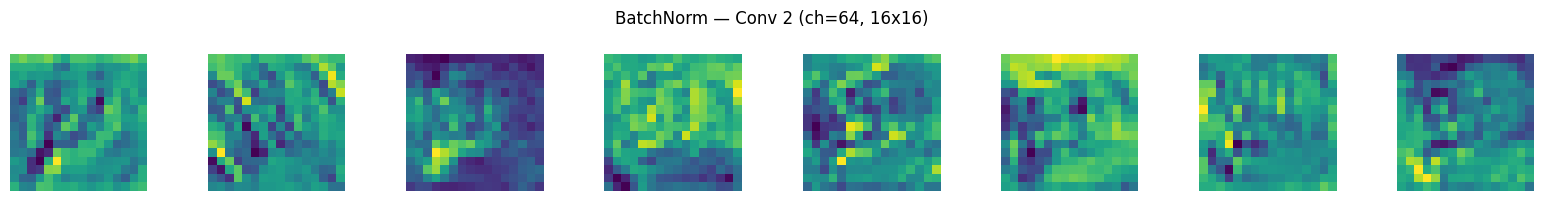

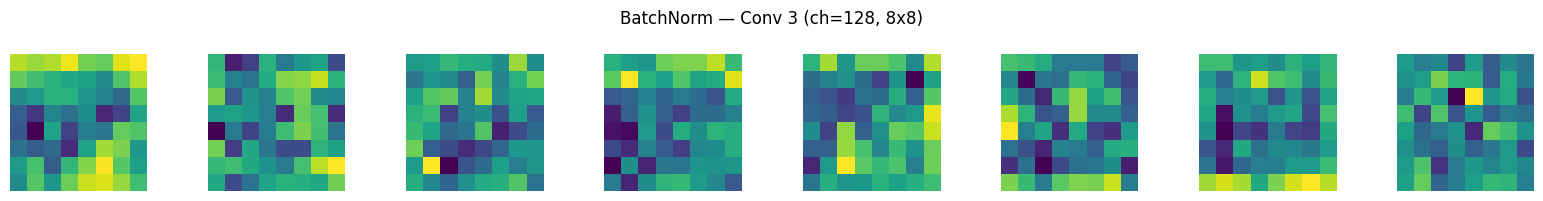

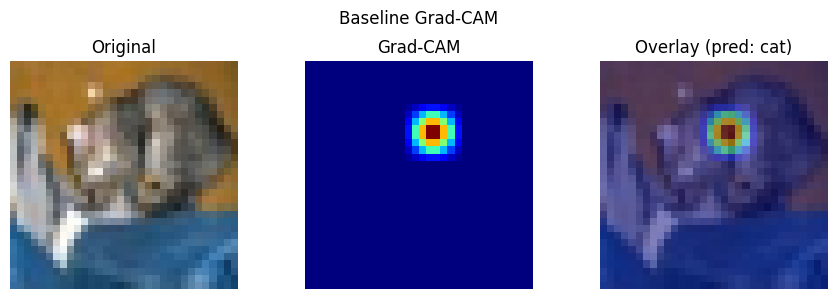

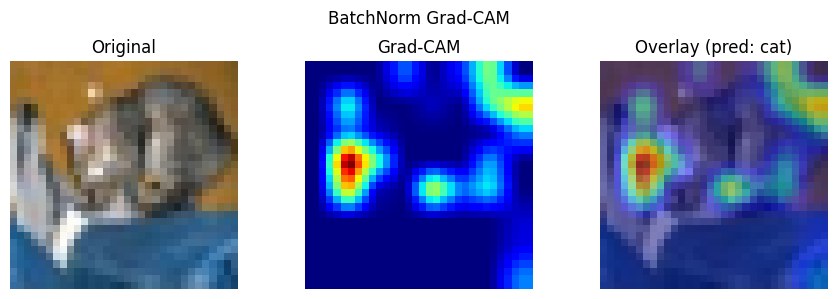


=== 클래스: car ===


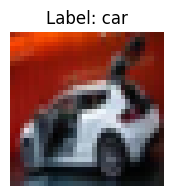

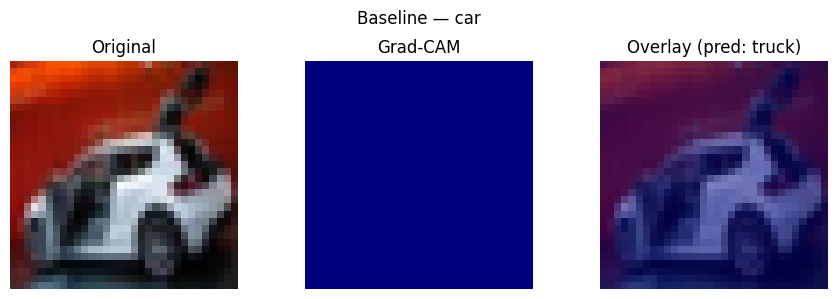

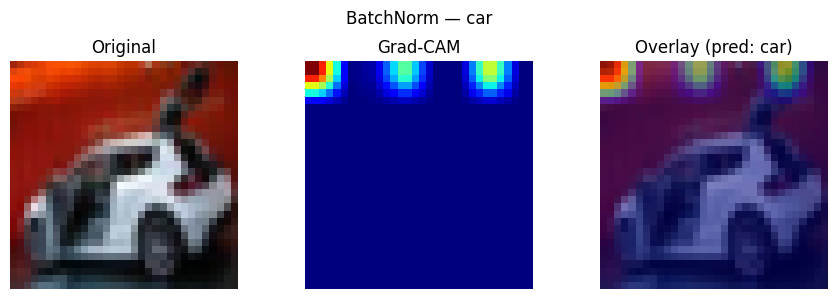


=== 클래스: cat ===


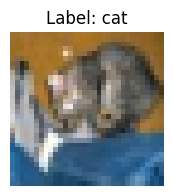

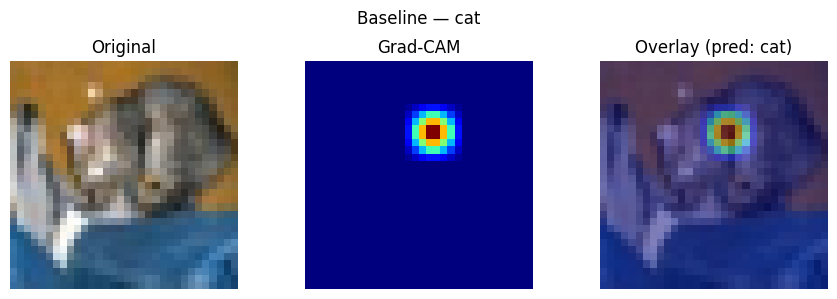

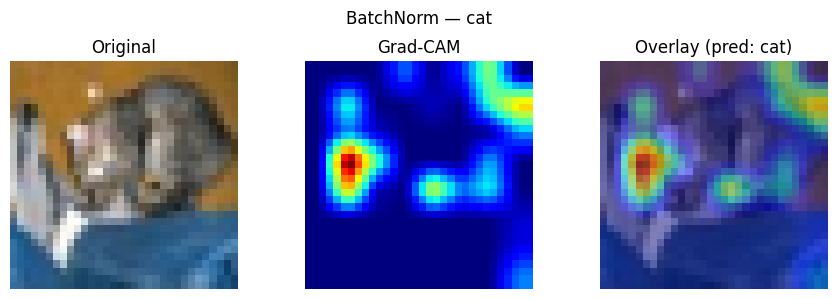


=== 클래스: horse ===


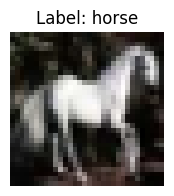

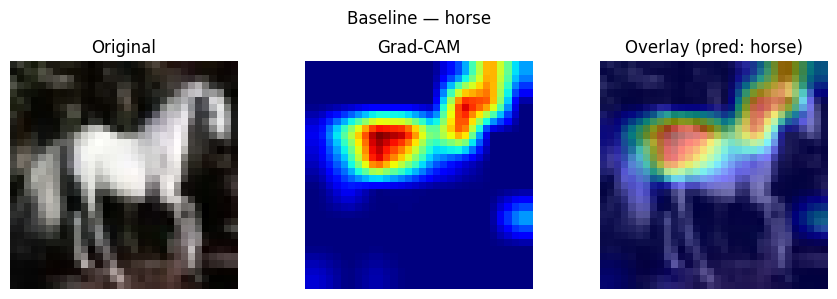

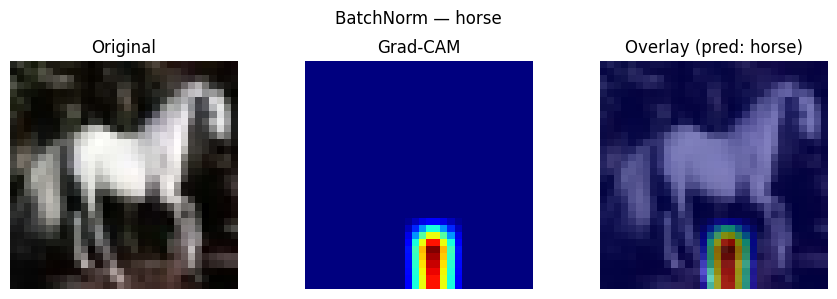

In [14]:
# --- Pick a sample image for visualization ---
sample_image, sample_label = testset[0]
show_original_image(sample_image, sample_label)

# TODO: Visualize first-layer filters for Baseline and BatchNorm models
visualize_filters(baseline, title="Baseline Filters")
visualize_filters(bn_model, title="BatchNorm Filters")

# TODO: Visualize feature maps for both models on the sample image
visualize_feature_maps(baseline, sample_image, title="Baseline")
visualize_feature_maps(bn_model, sample_image, title="BatchNorm")

# TODO: Show Grad-CAM heatmaps for both models
show_grad_cam(baseline, sample_image, label=sample_label, title="Baseline Grad-CAM")
show_grad_cam(bn_model, sample_image, label=sample_label, title="BatchNorm Grad-CAM")

# TODO: Try at least 3 different images from different classes and compare.
#       Do the models focus on different regions?
target_classes = [1, 3, 7]  # car, cat, horse
for target_class in target_classes:
    for img, lbl in testset:
        if lbl == target_class:
            print(f'\n=== 클래스: {classes[target_class]} ===')
            show_original_image(img, lbl)
            show_grad_cam(baseline, img, label=lbl, title=f"Baseline — {classes[target_class]}")
            show_grad_cam(bn_model, img, label=lbl, title=f"BatchNorm — {classes[target_class]}")
            break

### 5-1. Observation Questions

1. Describe the patterns you see in the first-layer filters. Do they resemble edge detectors, color detectors, or something else?

  -> Baseline과 BatchNorm 둘 다 필터가 엣지 감지기보다는 색상 감지기 형태로 나타났습니다. 각 필터가 특정 색상 조합(빨강-초록, 파랑-보라, 노랑-초록 등)에 반응하는 패턴을 보입니다. 일반적으로 잘 학습된 CNN의 첫 레이어는 가로/세로선 같은 엣지 패턴이 나와야 하는데, CIFAR-10처럼 32×32의 작은 이미지에서는 색상 정보가 상대적으로 더 강하게 학습되는 경향이 있습니다.

2. How do feature maps change from the first conv layer to the last? What does this suggest about hierarchical feature learning?

  ->1행 Baseline Conv1 (32×32): 이미지가 크고 곡선/윤곽 패턴이 보임

  2행 Baseline Conv2 (16×16): 이미지 작아지고 더 단순해짐
  3행 Baseline Conv3 (8×8):  매우 작고 그냥 몇 개 점처럼 보임

4행 BatchNorm Conv1 (32×32): 마찬가지로 윤곽 보임
5행 BatchNorm Conv2 (16×16): 단순해짐
6행 BatchNorm Conv3 (8×8):  작고 추상적

3. Compare the Grad-CAM heatmaps of the Baseline and BatchNorm models. Does one focus on more relevant image regions?
->
Baseline:   작은 점 하나 → 고양이 얼굴 중앙 한 곳만 집중
BatchNorm:  두 개의 영역 → 몸통 + 다리 부분을 함께 봄

BatchNorm 모델이 더 넓은 영역을 보고 판단했습니다. 다만 두 모델 모두 귀나 수염 같은 고양이의 핵심 부위를 정확히 집중하지는 못했는데, 이는 32×32 해상도의 한계로 보임

4. Did you find any images where one model's attention (Grad-CAM) was clearly better than the other's? Describe what you found.
->Baseline — car:
  Grad-CAM이 전부 파란색 (완전히 비어있음)
  → 어디를 봐야 할지 전혀 모름
  → 예측도 틀림: pred = truck (car를 truck으로 오분류)

BatchNorm — car:
  이미지 상단에 활성화 영역 존재
  → 뭔가는 보고 있음
  → 예측 정답: pred = car

  ->
  Baseline — horse:
  말의 몸통과 목 부분에 넓게 활성화 → 꽤 잘 봄
  → 예측 정답: pred = horse

BatchNorm — horse:
  말의 다리 아래쪽(발굽 부근)에만 집중
  → 정답은 맞혔지만 의외의 부위를 봄
  → 예측 정답: pred = horse

*Your observations here*

---
## Task 6: Analysis

### 6-1. Compare Results

In [ ]:
# Final evaluation on the TEST set (only done here, after all tuning is complete)
print('Final Test Set Evaluation:')
print('=' * 40)
results = {}
for name, model in [('Baseline', baseline), ('Dropout', dropout_model),
                     ('BatchNorm', bn_model), ('Best Model', best_model)]:
    _, acc = evaluate(model, testloader)
    results[name] = acc
    print(f'  {name:15s}: {acc:.4f}')
print('=' * 40)

# --- Bar Chart ---
plt.figure(figsize=(8, 4))
colors = ['#4C72B0' if v >= 0.65 else '#C44E52' for v in results.values()]
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Test Accuracy')
plt.title('Regularization Comparison on CIFAR-10')
plt.ylim(0, 1)
plt.axhline(y=0.65, color='gray', linestyle='--', alpha=0.5, label='Minimum threshold (65%)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Auto-Grading ---
def compute_grade(best_acc):
    if best_acc >= 0.85: return 'A+'
    elif best_acc >= 0.82: return 'A'
    elif best_acc >= 0.79: return 'B+'
    elif best_acc >= 0.76: return 'B'
    elif best_acc >= 0.70: return 'C'
    else: return 'F'

thresholds = {
    'Baseline': 0.65,
    'Dropout': 0.65,
    'BatchNorm': 0.70,
    'Best Model': 0.70,
}

print('=' * 45)
print('           AUTO-GRADE REPORT')
print('=' * 45)
all_pass = True
for task, threshold in thresholds.items():
    acc = results[task]
    passed = acc >= threshold
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_pass = False
    print(f'  {task:20s}: {acc:.1%}  (>= {threshold:.0%})  [{status}]')

best = results['Best Model']
grade = compute_grade(best)
print('-' * 45)
print(f'  Best Model Accuracy : {best:.1%}')
print(f'  Grade               : {grade}')
if not all_pass:
    print('  WARNING: Some tasks below minimum threshold!')
print('=' * 45)

### 6-2. Training Curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, hist in [('Baseline', hist_baseline), ('Dropout', hist_dropout),
                    ('BatchNorm', hist_bn), ('Best', hist_best)]:
    ax1.plot(hist['loss'], label=name)
    ax2.plot(hist['acc'], label=name)

ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.set_title('Training Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

### 6-3. Questions (Answer in text cells below)

1. Which regularization technique (Dropout vs BatchNorm) gave the bigger improvement over the baseline? Why do you think so?
2. Compare the training curves (loss & accuracy) of the baseline vs. your best model. What differences do you observe regarding overfitting?
3. Based on your Grad-CAM visualizations from Task 5, which model (Baseline vs BatchNorm) focuses on more task-relevant image regions? How might this relate to their accuracy difference?

*Your answers here*